# Four GP Fit Examples

This notebook reads one light curve from each class, fits the GP model, and makes one four-panel summary plot.

In [1]:
import pickle as pkl
import re
from pathlib import Path
from glob import glob
import warnings
warnings.filterwarnings('ignore')
import time

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline

from astropy.io import fits
from astropy.table import Table

import george
from george import kernels

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator

from functions import (
    read_fits, prep_input, prep_gp, fit_gp, opt_gp,
    binning_data, multiscale_peaks, predict_gp, prep_for_fit,
    get_metrics, l2_distance, find_valid_rows,
    rot_var_gp_fit, flare_fit
)
from gp_model_params import info
from tqdm.notebook import tqdm

np.random.seed(42)


In [19]:
# Global matplotlib style for paper figures
plt.rcParams.update({
    "font.size"          : 13,
    "axes.labelsize"     : 14,
    "axes.titlesize"     : 14,
    "legend.fontsize"    : 11,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi"         : 120,
})

# Color-blind-friendly palette
C0, C1, C2, C3, C4, C5, C6, C7 = '#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7'
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['#000000', '#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7'])

In [44]:
# Paths
home = str(Path.home())

OUTPUT_PLOT = 'output/plots/'
OUTPUT_FILE = 'output/'

Path(OUTPUT_PLOT).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_FILE).mkdir(parents=True, exist_ok=True)


## Load Roman Cadence Arrays

In [4]:
# Load Roman Galactic Bulge cadence time arrays
Roman_sampling_short  = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long   = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_long2  = np.load('lc_example/roman_times_longcadence2.npy')

Roman_sampling_short  -= Roman_sampling_short.min()
Roman_sampling_long   -= Roman_sampling_long.min()
Roman_sampling_long2  -= Roman_sampling_long2.min()

Roman_max_short_time = Roman_sampling_short.max()

t_base       = Roman_sampling_short
t_base_long  = Roman_sampling_long
t_base_long2 = Roman_sampling_long2

t_regular = np.linspace(0, Roman_max_short_time, 750_000)

print(f"Short cadence  : {len(t_base):,} pts  |  span = {Roman_max_short_time:.1f} d")
print(f"Long cadence 1 : {len(t_base_long):,} pts  |  span = {t_base_long.max():.1f} d")
print(f"Long cadence 2 : {len(t_base_long2):,} pts  |  span = {t_base_long2.max():.1f} d")


Short cadence  : 50,700 pts  |  span = 982.0 d
Long cadence 1 : 1,704 pts  |  span = 981.8 d
Long cadence 2 : 1,704 pts  |  span = 981.8 d


## LPV Example

In [5]:
# Load one OGLE LPV light curve
TP_LPV   = 'LPV'
BAND_LPV = 'I'

DIREC_LPV = home + f'/Research_data/Bulge_Variables/{TP_LPV}/'
period_file_lpv = home + f'/Research_data/Bulge_Variables/{TP_LPV}/BLG_{TP_LPV}_OGLE_periods.txt'
list_periods_lpv = np.genfromtxt(period_file_lpv, dtype='str')


direc_list = np.sort(glob(DIREC_LPV + '*.fits'))
print(f"Found {len(direc_list)} LPV FITS files.")

# Change the index to inspect a different source
demo_path_lpv = direc_list[91]
demo_id_lpv = demo_path_lpv.split('/')[-1].split('_')[0]

period_row_lpv = list_periods_lpv[list_periods_lpv[:, 0] == demo_id_lpv]
period_lpv = float(period_row_lpv[0][1]) if len(period_row_lpv) > 0 else info[TP_LPV]['exp_period']

period_fit_lpv, df_all_lpv = read_fits(demo_path_lpv, period=period_lpv, tp=TP_LPV)
df_lpv = df_all_lpv[df_all_lpv.band == BAND_LPV].reset_index(drop=True)

print(f"I-band : {len(df_lpv):,} points  "
      f"| t ∈ [{df_lpv.t.min():.1f}, {df_lpv.t.max():.1f}] days  "
      f"| <m> = {df_lpv.m.mean():.3f}")
df_lpv.head()


Found 4373 LPV FITS files.
I-band : 7,659 points  | t ∈ [0.0, 3525.7] days  | <m> = 15.966


,t,m,e,phase,band
0,0.00000,14.938,0.005,0.063860,I
1,1.03524,14.910,0.006,0.067116,I
2,3.01207,14.871,0.005,0.073332,I
3,5.05861,14.834,0.005,0.079768,I
4,6.05394,14.816,0.005,0.082898,I


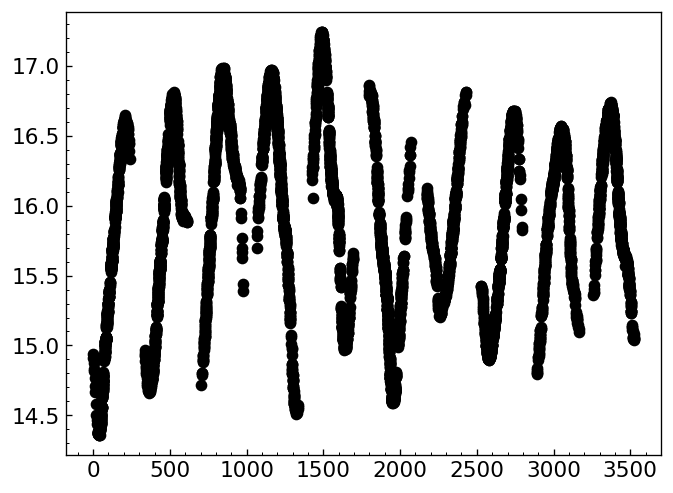

In [6]:
plt.scatter(df_lpv.t, df_lpv.m)

In [7]:
# Fit the LPV GP model
df_lpv_modified = prep_for_fit(df_lpv, period_lpv, info[TP_LPV])
# df_lpv_modified = df_lpv
gp_lpv = prep_gp(info[TP_LPV], period_lpv, verbose=True)
x_lpv, y_lpv, e_lpv = prep_input(
    df_lpv_modified, TP_LPV, period_lpv, info[TP_LPV], Roman_max_short_time
)

if not np.isinf(info[TP_LPV]['n_phs']):
    if len(x_lpv) / info[TP_LPV]['n_phs'] > 150:
        info[TP_LPV]['fit_binned'] = True
        tot_ideal_len_lpv = info[TP_LPV]['n_phs'] * info[TP_LPV]['count_per_bins']
    else:
        info[TP_LPV]['fit_binned'] = False
        tot_ideal_len_lpv = np.nan
else:
    tot_ideal_len_lpv = 1500 if len(x_lpv) > 1500 else np.nan
    info[TP_LPV]['fit_binned'] = len(x_lpv) > 1500

x_lpv_binned, y_lpv_binned, e_lpv_binned, regular_sampling_fit_lpv = binning_data(
    x_lpv, y_lpv, e_lpv, info[TP_LPV], n_bins=tot_ideal_len_lpv
)

valid_lpv = ~np.isnan(e_lpv_binned)
x_lpv_binned = x_lpv_binned[valid_lpv]
y_lpv_binned = y_lpv_binned[valid_lpv]
e_lpv_binned = e_lpv_binned[valid_lpv]

print(f"Binned size : {len(x_lpv_binned)} points  (from {len(x_lpv)})")

# info[TP_LPV]['gp_opt_s_param'] = 1

if info[TP_LPV]['gp_opt']:
    gp_lpv.compute(x_lpv_binned, e_lpv_binned)
    gp_lpv = opt_gp(gp_lpv.kernel.parameter_vector, gp_lpv,
                    x_lpv_binned, y_lpv_binned,
                    s=info[TP_LPV]['gp_opt_s_param'])
else:
    gp_lpv.compute(x_lpv_binned, e_lpv_binned)

y_lpv_median = np.median(y_lpv)

x_lpv_display = np.linspace(x_lpv_binned.min(), x_lpv_binned.max(), 2000)
gp_lpv_mean, gp_lpv_var = gp_lpv.predict(y_lpv_binned, x_lpv_display, return_var=True)
gp_lpv_std = np.sqrt(gp_lpv_var)

print("LPV GP fit complete.")


Setting up the GP...
Successfully set up the GP.
Binned size : 915 points  (from 4102)
LPV GP fit complete.


## DN Example

In [8]:
# Load one OGLE DN light curve
TP_DN = 'CV'
TP_DN   = 'DN'
BAND_DN = 'I'

DIREC_DN = home + f'/Research_data/Bulge_Variables/{TP_DN}/'

PEAK_SCALES        = [0.1, 0.5, 2, 5, 15]
MIN_SCALES         = 2
MERGE_WINDOW       = 5
MIN_PROMINENCE     = 0.05
MIN_SEPARATION     = 3.0
THRESHOLD_MAG      = -0.01
GP_THRESHOLD       = -0.001

direc_list_dn = np.sort(glob(DIREC_DN + '*.fits'))
print(f"Found {len(direc_list_dn)} DN FITS files.")

demo_path_dn = direc_list_dn[0]
demo_id_dn   = demo_path_dn.split('/')[-1].split('_')[0]

period_dn, df_all_dn = read_fits(demo_path_dn, period=np.nan, tp=TP_DN)
df_dn = df_all_dn[df_all_dn.band == BAND_DN].reset_index(drop=True)

if df_dn.t.min() > 0:
    df_dn = df_dn.copy()
    df_dn['t'] = df_dn['t'] - df_dn['t'].min()

print(f"I-band data : {len(df_dn):,} points  |  "
      f"span {df_dn.t.min():.1f} – {df_dn.t.max():.1f} days")
df_dn.head()


Found 198 DN FITS files.
I-band data : 9,776 points  |  span 0.0 – 4469.9 days


,t,m,e,phase,band
0,0.00000,18.261,0.069,2.452126e+06,I
1,4.07473,18.217,0.039,2.452130e+06,I
2,7.01630,16.589,0.011,2.452133e+06,I
3,10.92036,18.289,0.056,2.452137e+06,I
4,15.93210,18.218,0.042,2.452142e+06,I


In [9]:
# Fit the DN peak GP model
t_min_step_dn = np.min(np.diff(df_dn.t.values))
inds_dn = np.where(np.diff(df_dn.t.values) > 50)[0]

df_dn_modified = df_dn.copy()
for ind in inds_dn:
    time_gap = df_dn_modified.t.iloc[ind + 1] - df_dn_modified.t.iloc[ind] + t_min_step_dn
    df_dn_modified.loc[df_dn_modified.index[ind + 1]:, 't'] -= time_gap

mags_dn = df_dn_modified.m.values
baseline_mag_dn = np.percentile(mags_dn, 50)

y_mags_dn = mags_dn.copy()
outburst_mask_dn = mags_dn > (THRESHOLD_MAG + baseline_mag_dn)
y_mags_dn[outburst_mask_dn] = baseline_mag_dn
y_mags_dn -= np.median(y_mags_dn)

df_dn_modified = df_dn_modified.copy()
df_dn_modified['m'] = y_mags_dn

info_cv = info[TP_DN].copy()
x_dn_raw, y_dn_raw, e_dn_raw = prep_input(
    df_dn_modified, TP_DN, np.nan, info_cv, df_dn_modified.t.max()
)

if len(x_dn_raw) > 1500:
    info_cv['fit_binned'] = True
    x_dn_b, y_dn_b, e_dn_b, _ = binning_data(x_dn_raw, y_dn_raw, e_dn_raw, info_cv, n_bins=1500)
else:
    info_cv['fit_binned'] = False
    x_dn_b, y_dn_b, e_dn_b, _ = binning_data(x_dn_raw, y_dn_raw, e_dn_raw, info_cv, n_bins=np.nan)

valid_dn = ~np.isnan(e_dn_b)
x_dn_b = x_dn_b[valid_dn]
y_dn_b = y_dn_b[valid_dn]
e_dn_b = e_dn_b[valid_dn]

baseline_dn_b = np.percentile(y_dn_b, 50)
y_dn_clean = y_dn_b.copy()
mask_dn_b = y_dn_b > -0.7
y_dn_clean[mask_dn_b] = baseline_dn_b
y_dn_clean -= np.median(y_dn_clean)

t_peaks_dn, widths_dn = multiscale_peaks(
    x_dn_b, y_dn_clean,
    scales=PEAK_SCALES,
    min_scales=MIN_SCALES,
    merge_window=MERGE_WINDOW,
    min_prominence=MIN_PROMINENCE,
    min_separation=MIN_SEPARATION,
)

print(f"Detected {len(t_peaks_dn)} candidate outburst peak(s).")

peaks_list_dn = []

for j, (t_peak, w) in enumerate(tqdm(
    zip(t_peaks_dn, widths_dn), total=len(t_peaks_dn), desc='Fitting DN peak GP templates'
)):
    if w > 100:
        continue

    if j < len(t_peaks_dn) - 1:
        if (abs(t_peak - t_peaks_dn[j + 1]) < 5) and (abs(w - widths_dn[j + 1]) < 0.1):
            continue

    dt = w * 1.5
    ind_pk = (x_dn_b > t_peak - dt) & (x_dn_b < t_peak + dt)
    if ind_pk.sum() == 0:
        ind_pk = (x_dn_b > t_peak - 2.5 * w) & (x_dn_b < t_peak + 2.5 * w)

    t_win = x_dn_b[ind_pk]
    m_win = y_dn_b[ind_pk]
    e_win = e_dn_b[ind_pk]

    if len(m_win) < 11:
        continue

    t_shifted = t_win - t_win.min()
    x_log = -1 * np.log10(t_shifted + 0.001)
    x_new = np.linspace(0, t_win.max() - t_win.min(), int(dt * 10))
    info[TP_DN]['gp_opt_s_param'] = 0.9
    gp_dn = prep_gp(info[TP_DN], np.nan)
    gp_dn = fit_gp(x_log, m_win, e_win, info[TP_DN], gp_dn)

    x_new_log = -1 * np.log10(x_new + 0.001)
    y_pred, y_var = gp_dn.predict(m_win, x_new_log, return_var=True)
    y_std = np.sqrt(y_var)

    if len(y_pred) == 0 or not np.any(np.isfinite(y_pred)):
        continue

    y_pred_clip = y_pred.copy()
    y_pred_clip[y_pred > GP_THRESHOLD] = 0.0

    if np.max(y_pred_clip) < -0.1:
        continue
    if np.std(y_pred_clip) < 0.3:
        continue
    if y_pred_clip[-1] < -0.5 or y_pred_clip[0] < -0.5:
        continue

    interp_y = interp1d(x_new, y_pred_clip, kind='linear',
                        bounds_error=False, fill_value=np.nan)

    peaks_list_dn.append({
        "gp": gp_dn,
        "xfit": x_log,
        "yfit": m_win,
        "x": t_win,
        "y": m_win,
        "e": e_win,
        "x_new": x_new,
        "y_new": y_pred_clip,
        "y_std": y_std,
        "interpol": interp_y,
        "t_peak": t_peak,
    })

if len(peaks_list_dn) == 0:
    raise RuntimeError("No DN peaks accepted. Try another DN source.")

dn_peak = peaks_list_dn[1]
print(f"Accepted {len(peaks_list_dn)} / {len(t_peaks_dn)} peaks.")

Detected 33 candidate outburst peak(s).


Fitting DN peak GP templates:   0%|          | 0/33 [00:00<?, ?it/s]

Accepted 6 / 33 peaks.


In [10]:
dn_peak = peaks_list_dn[1]

## Flare Example

In [11]:
# Load one TESS flare light curve
TP_FLARE   = 'Flares_TESS'
BAND_FLARE = 'TESS'

TESS_PATH = home + '/Research_data/Bulge_Variables/Flares_TESS/'

all_paths_flare = np.sort(glob(TESS_PATH + '*.fits'))
print(f"Found {len(all_paths_flare)} TESS flare FITS files.")

demo_path_flare = all_paths_flare[1]
tic_id = demo_path_flare.split('/')[-1].split('_')[0].split('c')[-1]

with fits.open(demo_path_flare) as hdul:
    header_flare = hdul[1].header
    hd_data_flare = hdul[1].data

df_lc_flare = Table(hd_data_flare).to_pandas()
df_flare = df_lc_flare[["BTJD", "mag", "mag_err"]].rename(
    columns={"BTJD": "t", "mag": "m", "mag_err": "e"}
)

flare_nums = sorted({
    int(re.search(r"F(\d+)", k).group(1))
    for k in header_flare.keys()
    if re.match(r"F\d+-EXT", k)
})

flares = [
    {
        "flare_id": n,
        "ext": header_flare.get(f"F{n}-EXT"),
        "btjd_start": header_flare.get(f"F{n}-BTJD-START"),
        "btjd_peak": header_flare.get(f"F{n}-BTJD-PEAK"),
        "btjd_stop": header_flare.get(f"F{n}-BTJD-STOP"),
        "mag_start": header_flare.get(f"F{n}-MAG-START"),
        "mag_peak": header_flare.get(f"F{n}-MAG-PEAK"),
        "mag_stop": header_flare.get(f"F{n}-MAG-STOP"),
    }
    for n in flare_nums
]
df_header_flare = pd.DataFrame(flares)

t_obs_flare = df_flare.t.values
m_obs_flare = df_flare.m.values
e_obs_flare = df_flare.e.values

df_header_flare.head()


Found 68 TESS flare FITS files.


,flare_id,ext,btjd_start,btjd_peak,btjd_stop,mag_start,mag_peak,mag_stop
0,1,1,2095.722896,2095.730303,2095.840027,10.248152,None,10.251543
1,2,1,2103.109531,2103.113234,2103.138697,10.254030,None,10.255319
2,3,1,2104.954208,2104.956523,2104.981060,10.250636,None,10.250287
3,4,1,2105.084300,2105.086152,2105.132449,10.243996,None,10.241586
4,5,1,2109.473400,2109.479650,2109.516455,10.245737,None,10.247958


In [38]:
# Fit the flare GP models
threshold_mag_flare = -0.1
baseline_mag_flare = np.percentile(m_obs_flare, 50)

y_sim_flare = m_obs_flare.copy()
mask_flare = m_obs_flare < baseline_mag_flare + threshold_mag_flare
y_sim_flare[mask_flare] = np.ones_like(y_sim_flare[mask_flare]) * baseline_mag_flare
y_sim_flare = y_sim_flare - np.median(y_sim_flare)

print("Fitting GP baseline ...")
gp_base_flare, data_base_flare = rot_var_gp_fit(
    t_obs_flare, y_sim_flare, e_obs_flare, n_bins=1000
)

m_data_flare, t_data_flare, m_err_flare = (
    data_base_flare[0], data_base_flare[1], data_base_flare[2]
)

y_base_regular_flare, y_var_regular_flare = gp_base_flare.predict(
    m_data_flare, t_regular, return_var=True
)

info_flare = info[TP_FLARE].copy()
period_flare = np.nan

flare_dics = {}

for _, row in tqdm(df_header_flare.iterrows(), total=len(df_header_flare),
                   desc='Fitting individual flares'):
    f = int(row.flare_id)

    if row.btjd_peak > df_flare.t.max():
        continue

    df_fl = df_flare[(df_flare.t < row.btjd_stop) & (df_flare.t > row.btjd_start)].copy()

    if df_fl.t.min() > 0:
        df_fl['t'] = df_fl['t'] - df_fl['t'].min()

    x_fl, y_fl, e_fl = prep_input(
        df_fl, TP_FLARE, period_flare, info_flare, Roman_max_short_time
    )

    dic = flare_fit(x_fl, y_fl, e_fl, info_flare, period_flare)

    # y_pred, y_var = dic["gp"].predict(dic["y"], dic["x_new"], return_var=True)
    # dic["y_std"] = np.sqrt(y_var)

    x_new_gp = -1 * np.log10(dic["x_new"] + 0.001)

    y_pred, y_var = dic["gp"].predict(dic["yfit"], x_new_gp, return_var=True)
    dic["y_std"] = np.sqrt(y_var)
    dic["e"] = e_fl
    flare_dics[f] = dic

if len(flare_dics) == 0:
    raise RuntimeError("No flares fitted. Try another TESS source.")

flare_id = list(flare_dics.keys())[0]
flare_peak = flare_dics[flare_id]

print(f"Fitted {len(flare_dics)} flare(s).")

Fitting GP baseline ...


Fitting individual flares:   0%|          | 0/5 [00:00<?, ?it/s]

Fitted 5 flare(s).


## Be Star Example

In [13]:
# Load one Gaia Be star light curve
TP_BE   = 'Be'
BAND_BE = 'G'

DATA_PATH_BE = home + '/Research_data/GAIA BE stars/Gaia_Be_stars_candidates/gaia_science_alerts_be_stars_lightcurves/'
period_be = np.nan

lc_list_be = sorted(glob(DATA_PATH_BE + '*.csv'))
print(f"Found {len(lc_list_be)} light curve files.")

demo_path_be = lc_list_be[0] #DATA_PATH_BE + 'Gaia23cne.csv'
if not Path(demo_path_be).exists():
    demo_path_be = lc_list_be[1]

demo_id_be = Path(demo_path_be).stem
print(f"Demo source   : {demo_id_be}")

loaded_df_be = pd.read_csv(demo_path_be).reset_index(drop=True)
df_be = loaded_df_be.rename(columns={"JD(TCB)": "t", "mag": "m", "err": "e"})

print(f"G-band : {len(df_be):,} points  "
      f"| t ∈ [{df_be.t.min():.1f}, {df_be.t.max():.1f}] JD days  "
      f"| <m> = {df_be.m.mean():.3f}")
df_be.head()


Found 270 light curve files.
Demo source   : Gaia18dek
G-band : 222 points  | t ∈ [2456865.2, 2460309.4] JD days  | <m> = 17.535


,t,m,e
0,2.456865e+06,17.66,0.021459
1,2.456865e+06,17.63,0.021077
2,2.456866e+06,17.64,0.021203
3,2.456866e+06,17.64,0.021203
4,2.456866e+06,17.64,0.021203


In [14]:
# Fit the Be-star GP model
if df_be.t.min() > 0:
    df_be['t'] = df_be['t'] - df_be['t'].min()

inds_be = np.where(np.diff(df_be.t.values) > 500)[0]
t_min_be = np.min(np.diff(df_be.t.values))

df_be_modified = df_be.copy()
for ind in inds_be:
    time_gap = df_be_modified.t.iloc[ind + 1] - df_be_modified.t.iloc[ind] + t_min_be
    df_be_modified.loc[df_be_modified.index[ind + 1]:, 't'] -= time_gap

scale_factor_be = np.max(df_be_modified['t']) / 5
df_be_modified = df_be_modified.copy()
df_be_modified['t'] = df_be_modified['t'] / scale_factor_be

info[TP_BE]['gp_opt_s_param'] = 0
gp_be = prep_gp(info[TP_BE], period_be)

x_be, y_be, e_be = prep_input(
    df_be_modified, TP_BE, period_be, info[TP_BE], Roman_max_short_time
)

if len(x_be) > 130:
    info[TP_BE]['fit_binned'] = True
    x_be_binned, y_be_binned, e_be_binned, regular_sampling_fit_be = binning_data(
        x_be, y_be, e_be, info[TP_BE], n_bins=100
    )
else:
    info[TP_BE]['fit_binned'] = False
    x_be_binned, y_be_binned, e_be_binned, regular_sampling_fit_be = binning_data(
        x_be, y_be, e_be, info[TP_BE], n_bins=np.nan
    )

valid_be = ~np.isnan(e_be_binned)
x_be_binned = x_be_binned[valid_be]
y_be_binned = y_be_binned[valid_be]
e_be_binned = e_be_binned[valid_be]

y_be_median = np.percentile(y_be, 90)

info[TP_BE]['gp_opt_s_param'] = 4.5
gp_be = fit_gp(x_be_binned, y_be_binned, e_be_binned, info[TP_BE], gp_be)

gp_be_fit, cov_be = gp_be.predict(y_be_binned, x_be_binned, return_cov=True)
gp_be_std = np.sqrt(np.diag(cov_be))

sort_idx_be = np.argsort(x_be_binned)
cs_be_fit = CubicSpline(x_be_binned[sort_idx_be], gp_be_fit[sort_idx_be])
cs_be_std = CubicSpline(x_be_binned[sort_idx_be], gp_be_std[sort_idx_be])

x_be_display = np.linspace(x_be_binned.min(), x_be_binned.max(), 800)
y_be_display = cs_be_fit(x_be_display)
std_be_display = np.abs(cs_be_std(x_be_display))

print("Be-star GP fit complete.")


Be-star GP fit complete.


## Four-Panel GP Fit Plot

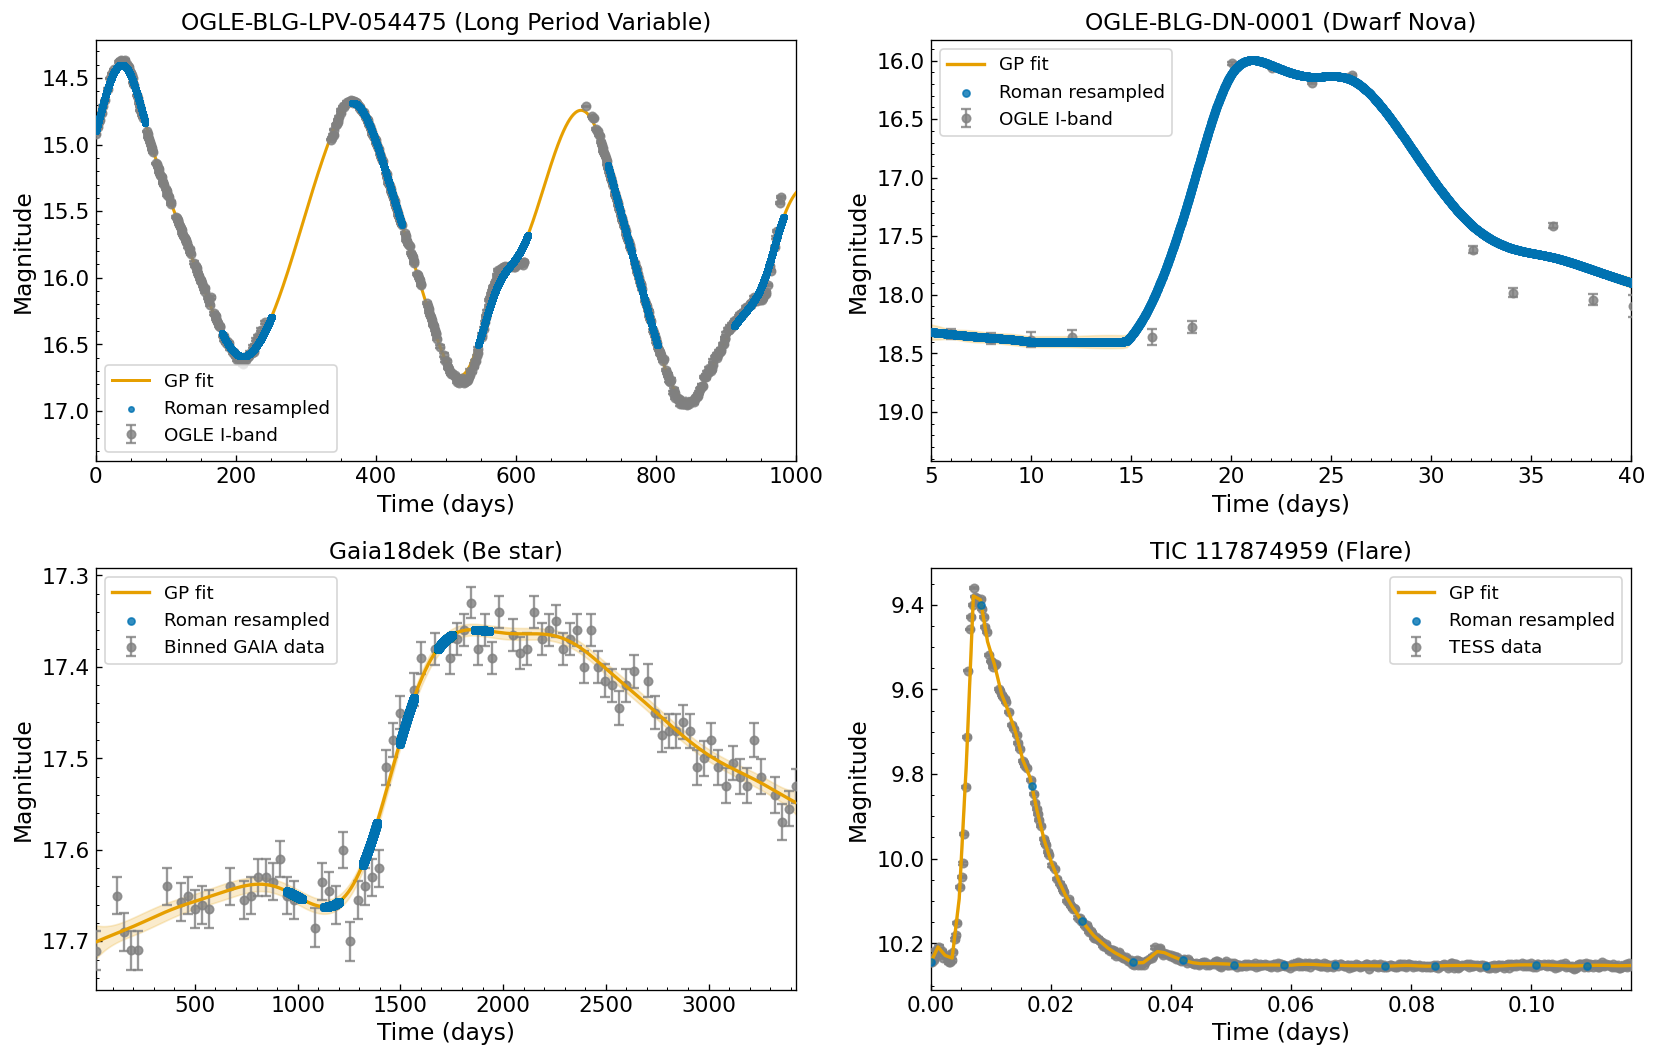

In [51]:
# Four-panel GP fit plot
dn_peak = peaks_list_dn[2]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

ax = axes[0]

ax.errorbar(
    x_lpv_binned, y_lpv_binned + y_lpv_median, yerr=e_lpv_binned,
    fmt='o', color='grey', alpha=0.8, zorder=3,markersize=5,
    elinewidth=1.4, capsize=3, capthick=1.4, rasterized=True,
    label='OGLE I-band'
)
ax.plot(
    x_lpv_display, gp_lpv_mean + y_lpv_median,
    color=C1, lw=1.8, label='GP fit', zorder=3
)
ax.fill_between(
    x_lpv_display,
    gp_lpv_mean + y_lpv_median - gp_lpv_std,
    gp_lpv_mean + y_lpv_median + gp_lpv_std,
    color=C1, alpha=0.2
)
roman_t_lpv = t_base[(t_base >= x_lpv_display.min()) & (t_base <= x_lpv_display.max())]
roman_y_lpv = np.interp(roman_t_lpv, x_lpv_display, gp_lpv_mean + y_lpv_median)
ax.scatter(
    roman_t_lpv, roman_y_lpv,
    s=10, alpha=0.8, color=C5, zorder=5, rasterized=True,
    label='Roman resampled'
)
ax.invert_yaxis()
ax.set_xlim(x_lpv_binned.min(), x_lpv_binned.max())
ax.set_xlabel('Time (days)')
ax.set_ylabel('Magnitude')
ax.set_title(f'{demo_id_lpv} (Long Period Variable)')
ax.legend()
ax.set_xlim(0, 1000)
ax.xaxis.set_minor_locator(AutoMinorLocator())

ax = axes[1]
dn_t_loc = dn_peak['x'] - dn_peak['x'].min()
baseline = 18.4
ax.errorbar(
    dn_t_loc, dn_peak['y']+baseline, yerr=dn_peak['e'],
    fmt='o', color='grey', alpha=0.8, zorder=3,markersize=5,
    elinewidth=1.4, capsize=3, capthick=1.4, rasterized=True,
    label='OGLE I-band'
)
ax.plot(
    dn_peak['x_new'], dn_peak['y_new']+baseline,
    color=C1, lw=2.0, zorder=4, label='GP fit'
)
ax.fill_between(
    dn_peak['x_new'],
    dn_peak['y_new']+baseline - dn_peak['y_std'],
    dn_peak['y_new']+baseline + dn_peak['y_std'],
    color=C1, alpha=0.2
)
roman_t_dn = t_base[t_base <= dn_peak['x_new'].max()]
roman_y_dn = np.interp(roman_t_dn, dn_peak['x_new'], dn_peak['y_new'])
ax.scatter(
    roman_t_dn, roman_y_dn+baseline,
    s=18, alpha=0.8, color=C5, zorder=5, rasterized=True,
    label='Roman resampled'
)
ax.invert_yaxis()
ax.set_xlim(dn_peak['x_new'].min(), dn_peak['x_new'].max())
ax.set_xlabel('Time (days)')
ax.set_ylabel('Magnitude')
ax.set_title(f'{demo_id_dn} (Dwarf Nova)')
ax.legend()
ax.set_xlim(5, 40)
ax.xaxis.set_minor_locator(AutoMinorLocator())

ax = axes[3]
ax.errorbar(
    flare_peak['x'], flare_peak['y'], yerr=flare_peak['e'],
    fmt='o', color='grey', alpha=0.8, zorder=3,markersize=5,
    elinewidth=1.4, capsize=3, capthick=1.4, rasterized=True,
    label='TESS data'
)
ax.plot(
    flare_peak['x_new'], flare_peak['y_new'],
    color=C1, lw=2.0, label='GP fit', zorder=4
)
ax.fill_between(
    flare_peak['x_new'],
    flare_peak['y_new'] - flare_peak['y_std'],
    flare_peak['y_new'] + flare_peak['y_std'],
    color=C1, alpha=0.2
)
roman_t_flare = t_base[t_base <= flare_peak['x_new'].max()]
roman_y_flare = np.interp(roman_t_flare, flare_peak['x_new'], flare_peak['y_new'])
ax.scatter(
    roman_t_flare, roman_y_flare,
    s=18, alpha=0.8, color=C5, zorder=5, rasterized=True,
    label='Roman resampled'
)
ax.invert_yaxis()
ax.set_xlim(flare_peak['x_new'].min(), flare_peak['x_new'].max())
ax.set_xlabel('Time (days)')
ax.set_ylabel('Magnitude')
ax.set_title(f'TIC {tic_id} (Flare)')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

ax = axes[2]

ax.errorbar(
    x_be_binned * scale_factor_be, y_be_binned + y_be_median, 
    yerr=e_be_binned, markersize=5,
    fmt='o', color='grey', alpha=0.8, zorder=3,
    elinewidth=1.4, capsize=3, capthick=1.4, rasterized=True,
    label='Binned GAIA data'
)
# ax.scatter(
#     x_be_binned * scale_factor_be, y_be_binned + y_be_median,
#     s=10, alpha=0.8, color='grey', zorder=3,
#     label='Binned Gaia data'
# )
ax.plot(
    x_be_display * scale_factor_be, y_be_display + y_be_median,
    color=C1, lw=2.0, zorder=4, label='GP fit'
)
ax.fill_between(
    x_be_display * scale_factor_be,
    y_be_display + y_be_median - std_be_display,
    y_be_display + y_be_median + std_be_display,
    color=C1, alpha=0.2
)
roman_t_be = t_base[t_base <= (x_be_binned * scale_factor_be).max()]+950
roman_y_be = cs_be_fit(roman_t_be / scale_factor_be) + y_be_median
ax.scatter(
    roman_t_be, roman_y_be,
    s=18, alpha=0.8, color=C5, zorder=5, rasterized=True,
    label='Roman resampled'
)
ax.invert_yaxis()
ax.set_xlim((x_be_binned * scale_factor_be).min(), (x_be_binned * scale_factor_be).max())
ax.set_xlabel('Time (days)')
ax.set_ylabel('Magnitude')
ax.set_title(f'{demo_id_be} (Be star)')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())

fig.tight_layout()
# plt.savefig(OUTPUT_PLOT + 'four_panel_gp_examples.png', dpi=150, bbox_inches='tight')
plt.rcParams['pdf.compression'] = 9
plt.savefig(OUTPUT_PLOT + 'examples.pdf', bbox_inches='tight', dpi=200)
plt.show()
